In [684]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.io import savemat

from importlib import reload
import kan
reload(kan)

from kan import KAN

In [685]:
x_min_test = 0
x_max_test = 1

In [686]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

#selected_indices = kan.select_equidistant_basis_indices(
#    total_basis=b_coef.shape[0],
#    num_selected=12,
#)
selected_indices = [8, 10, 12, 14, 16, 18, 20, 22]#np.arange(8,10)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

mat_folder = "new_affine_2-1-1_exports"
os.makedirs(mat_folder, exist_ok=True)

Selected indices: [8, 10, 12, 14, 16, 18, 20, 22]
Selected detunings: tensor([-1.3000e+11, -1.5000e+11, -1.7000e+11, -1.9000e+11, -2.1000e+11,
        -2.3000e+11, -2.5000e+11, -2.7000e+11])
Selected b_coef shape: torch.Size([8, 8])


In [687]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_train = 3000
n_test = 800

x_max_test = 1
x_min_test = 0
#input_abs_max = 3.0 #max(abs(x_min_test), abs(x_max_test))
#input_abs_max = [1.0, 3.0]

x_train = x_min_test + (x_max_test - x_min_test) * torch.rand(n_train, 2)
x_test = x_min_test + (x_max_test - x_min_test) * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y = 0.3 * x1**2 + torch.cos(3.0 * x2)

    return y

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [688]:
model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[6],
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    layer_type="photonic_interval_affine_clean",
    b_coef_selected=b_coef_selected,
    input_neg_max = [0.2, 3.0],
    input_pos_max = [1.0, 3.0],
    basis_min=0.05,
    basis_max=2.0,
    dropout_prob=0.0,
    debug=False,
)

model = model.to(device=device, dtype=torch.float64)

In [689]:
x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)
x_test = x_test.to(device=device, dtype=torch.float64)
y_test = y_test.to(device=device, dtype=torch.float64)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 5000

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"train loss = {loss.item():.8f} | "
            f"test loss = {test_loss.item():.8f}"
        )

Epoch     0 | train loss = 0.54390840 | test loss = 0.50683728
Epoch   500 | train loss = 0.00012112 | test loss = 0.00011280
Epoch  1000 | train loss = 0.00005663 | test loss = 0.00005455
Epoch  1500 | train loss = 0.00004137 | test loss = 0.00004023
Epoch  2000 | train loss = 0.00003163 | test loss = 0.00003094
Epoch  2500 | train loss = 0.00002424 | test loss = 0.00002401
Epoch  3000 | train loss = 0.00001935 | test loss = 0.00001948
Epoch  3500 | train loss = 0.00001632 | test loss = 0.00001665
Epoch  4000 | train loss = 0.00001431 | test loss = 0.00001472
Epoch  4500 | train loss = 0.00001284 | test loss = 0.00001328


In [690]:
model.print_photonic_affine_params()

Photonic interval affine parameters:

Layer 0: PhotonicBasisActivationLayerIntervalAffineClean
  in_count = 2
  out_count = 6
  input_neg_max = 0.2
  input_pos_max = 1.0
  basis interval = [0.05, 2.0]
  alpha shape = (2,)
  beta shape  = (2,)
  alpha values = [1.625 1.625]
  beta values  = [0.375 0.375]
  alpha unique = [1.625]
  beta unique  = [0.375]

Layer 1: PhotonicBasisActivationLayerIntervalAffineClean
  in_count = 6
  out_count = 1
  input_neg_max = 3.0
  input_pos_max = 3.0
  basis interval = [0.05, 2.0]
  alpha shape = (6,)
  beta shape  = (6,)
  alpha values = [0.32499999 0.32499999 0.32499999 0.32499999 0.32499999 0.32499999]
  beta values  = [1.02499998 1.02499998 1.02499998 1.02499998 1.02499998 1.02499998]
  alpha unique = [0.32499999]
  beta unique  = [1.02499998]


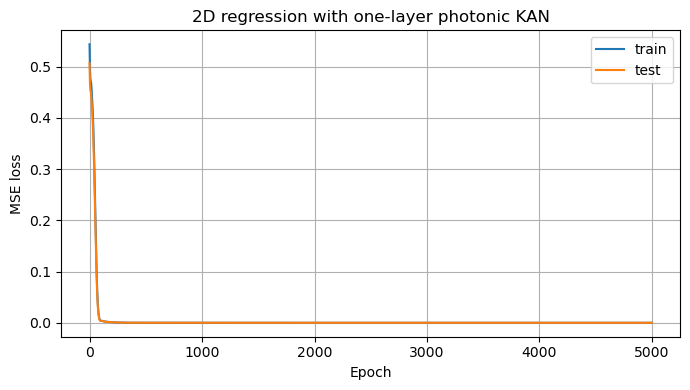

In [691]:
savemat(
    os.path.join(mat_folder, "loss_curves.mat"),
    {
        "plot_type": "loss_curves",
        "epoch": np.arange(num_epochs),
        "train_losses": np.array(train_losses),
        "test_losses": np.array(test_losses),
        "num_epochs": num_epochs,
    },
)

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer photonic KAN")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

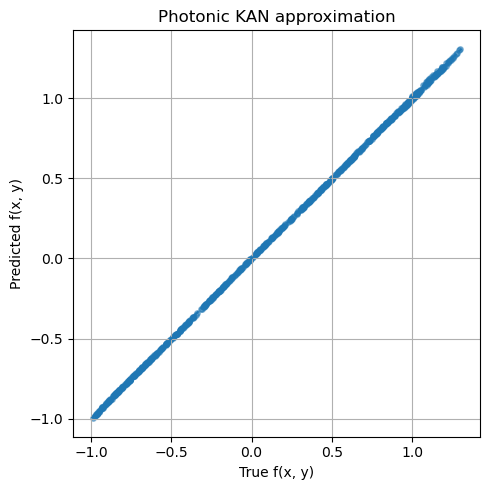

In [692]:
model.eval()

with torch.no_grad():
    y_pred_test = model(x_test)

savemat(
    os.path.join(mat_folder, "true_vs_pred_test.mat"),
    {
        "plot_type": "true_vs_pred_test",
        "x_test": x_test.detach().cpu().numpy(),
        "y_test": y_test.detach().cpu().numpy(),
        "y_pred_test": y_pred_test.detach().cpu().numpy(),
    },
)

plt.figure(figsize=(5, 5))
plt.scatter(
    y_test.detach().cpu().numpy(),
    y_pred_test.detach().cpu().numpy(),
    alpha=0.5,
    s=15,
)

minv = min(y_test.min().item(), y_pred_test.min().item())
maxv = max(y_test.max().item(), y_pred_test.max().item())

plt.plot([minv, maxv], [minv, maxv], linestyle="--")
plt.xlabel("True f(x, y)")
plt.ylabel("Predicted f(x, y)")
plt.title("Photonic KAN approximation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [693]:
model.eval()

with torch.no_grad():
    y_pred, activations = model(x_train, return_all=True)

z = activations[1]

z_min = z.min().item()
z_max = z.max().item()

print("hidden min:", z.min().item())
print("hidden max:", z.max().item())

hidden min: -2.7620151499455794
hidden max: 2.920837825162091


Saved MATLAB plot data to: new_affine_2-1-1_exports/basis_functions_L0_in0.mat


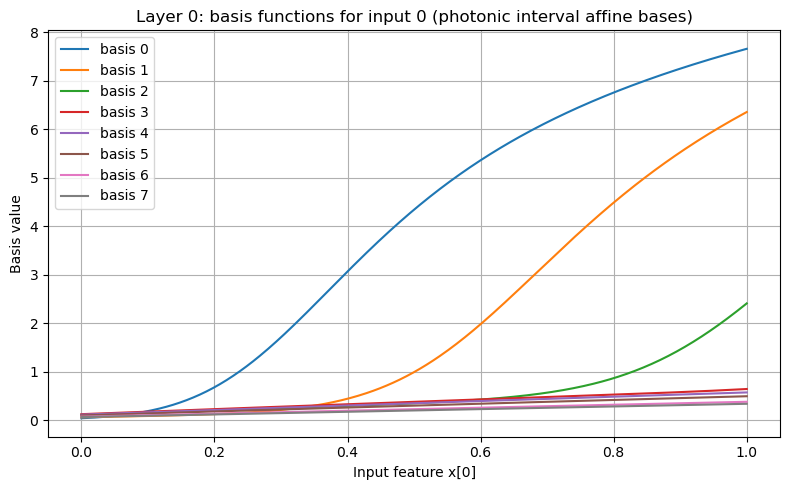

Saved MATLAB plot data to: new_affine_2-1-1_exports/basis_functions_L0_in1.mat


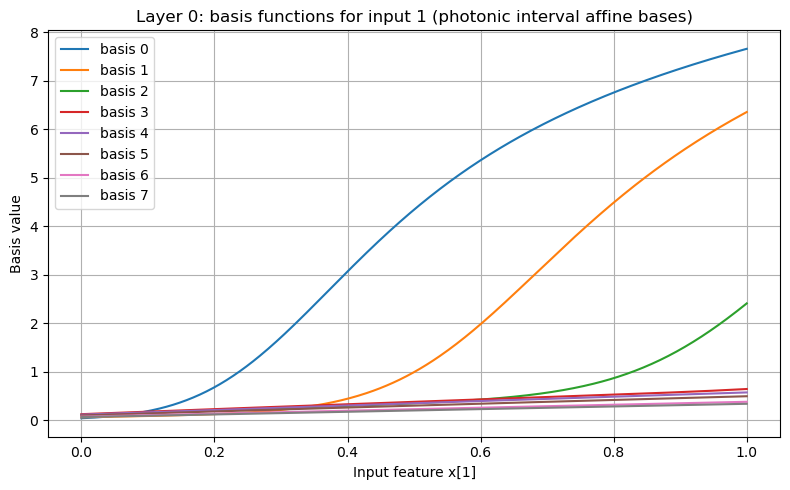

Saved MATLAB plot data to: new_affine_2-1-1_exports/basis_functions_L1_in0.mat


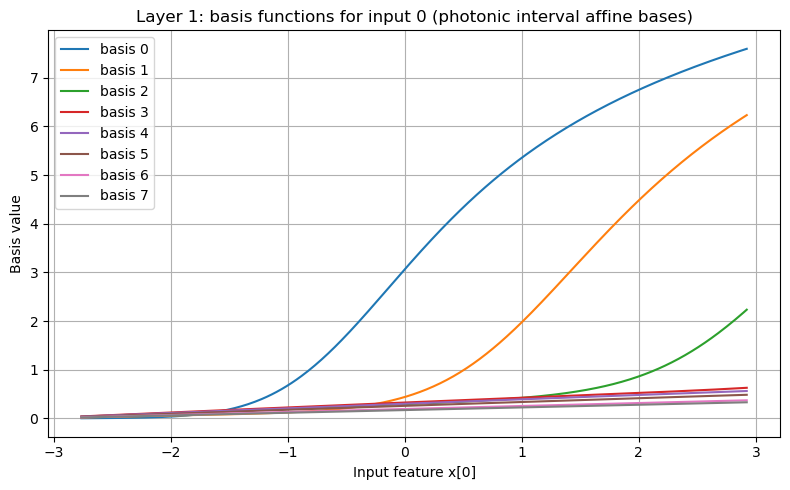

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_affine_2-1-1_exports/edge_function_L0_out0_in0.mat


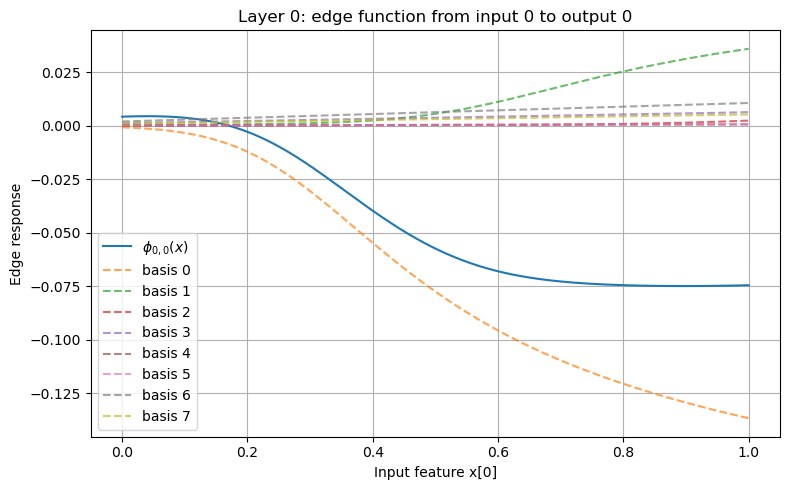

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_affine_2-1-1_exports/edge_function_L0_out0_in1.mat


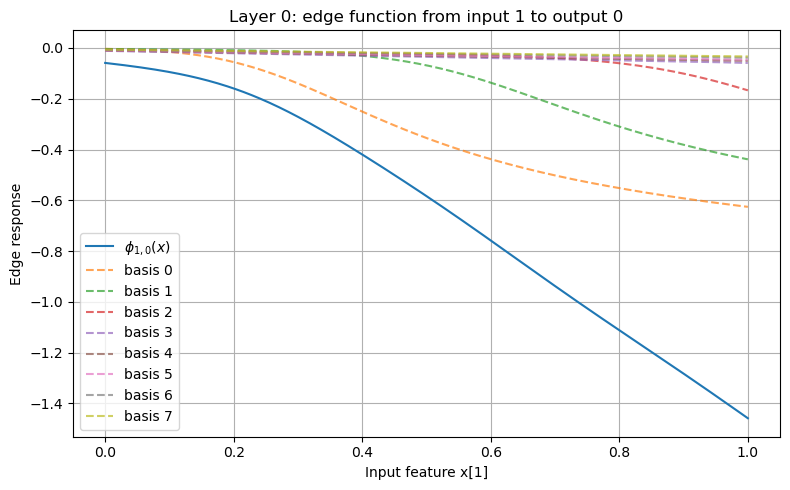

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_affine_2-1-1_exports/edge_function_L1_out0_in0.mat


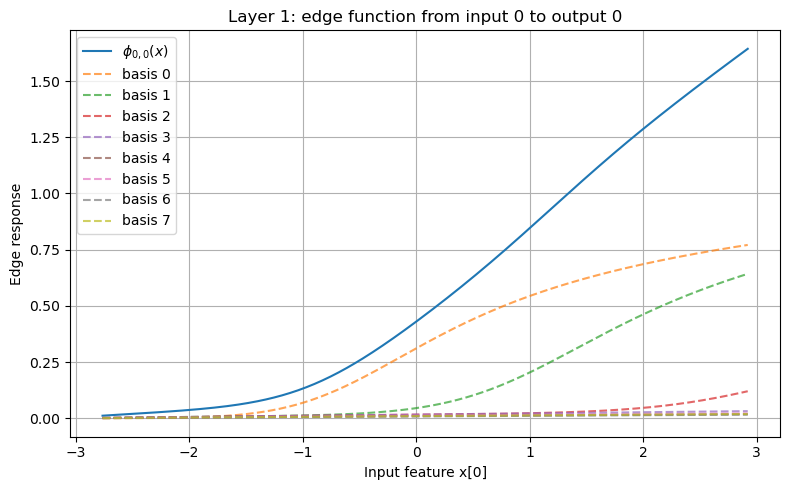

In [694]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), mat_export_path="basis_functions_L0_in0.mat", mat_export_dir=mat_folder)
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), mat_export_path="basis_functions_L0_in1.mat", mat_export_dir=mat_folder)
model.plot_basis_functions(layer_idx=1, in_idx=0, x_range=(z_min, z_max), mat_export_path="basis_functions_L1_in0.mat", mat_export_dir=mat_folder)

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=1, out_idx=0, in_idx=0, x_range=(z_min, z_max), show_basis=True, mat_export_path="edge_function_L1_out0_in0.mat", mat_export_dir=mat_folder)

Saved MATLAB plot data to: new_affine_2-1-1_exports/coefficient_vector_L0_out0_in0.mat


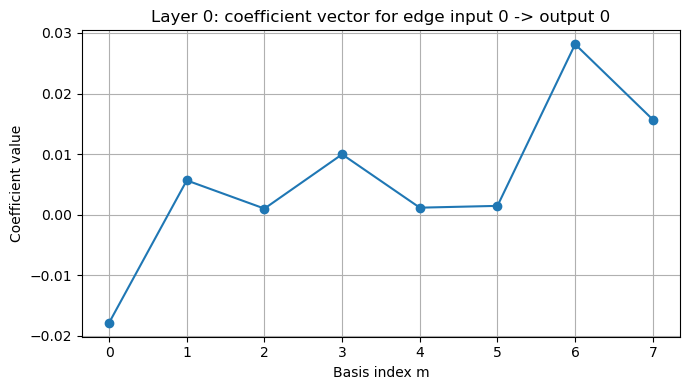

Saved MATLAB plot data to: new_affine_2-1-1_exports/coefficient_vector_L0_out0_in1.mat


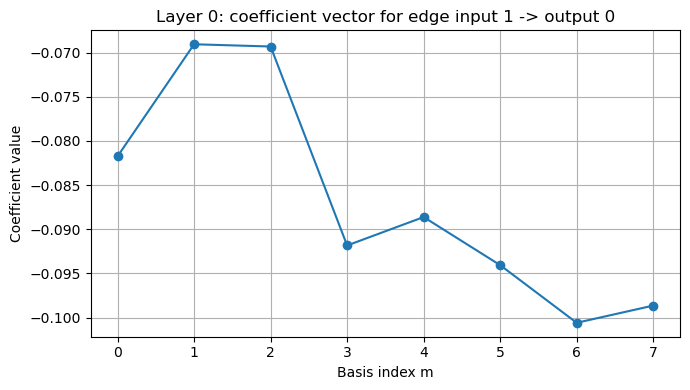

Saved MATLAB plot data to: new_affine_2-1-1_exports/coefficient_vector_L1_out0_in0.mat


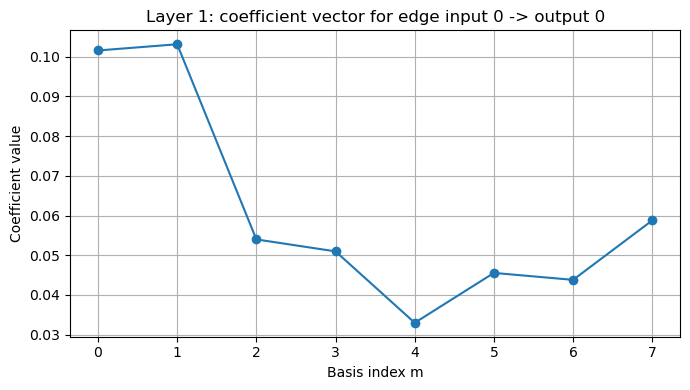

In [695]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0, mat_export_path="coefficient_vector_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1, mat_export_path="coefficient_vector_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=1, out_idx=0, in_idx=0, mat_export_path="coefficient_vector_L1_out0_in0.mat", mat_export_dir=mat_folder)

Saved MATLAB plot data to: new_affine_2-1-1_exports/target_approximation_varied_x0.mat


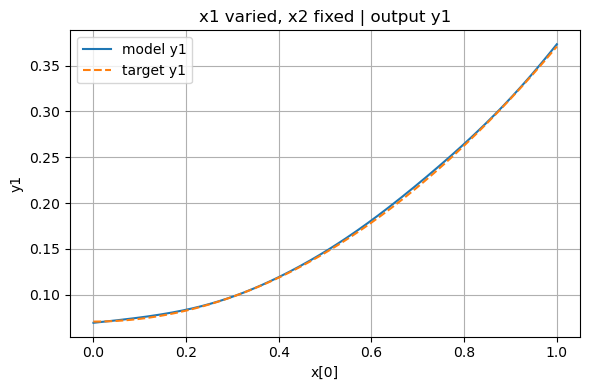

Saved MATLAB plot data to: new_affine_2-1-1_exports/target_approximation_varied_x1.mat


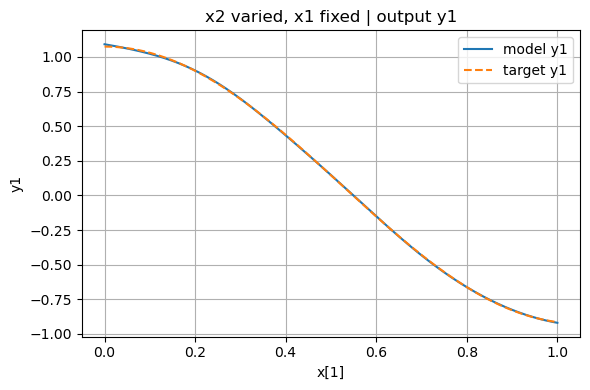

In [696]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.5, 0.5],
    resolution=400,
    mat_export_prefix="target_approximation",
    mat_export_dir=mat_folder,
)

Saved MATLAB plot data to: new_affine_2-1-1_exports/target_approximation_varied_x0.mat


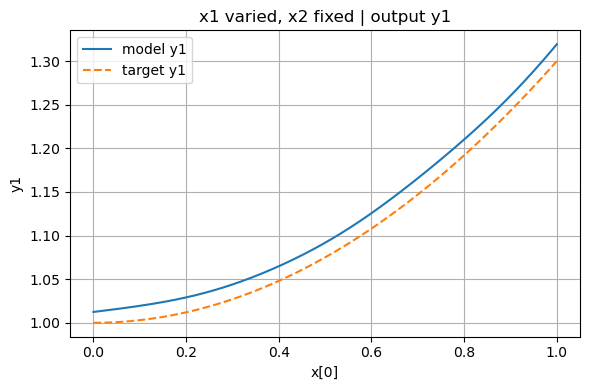

Saved MATLAB plot data to: new_affine_2-1-1_exports/target_approximation_varied_x1.mat


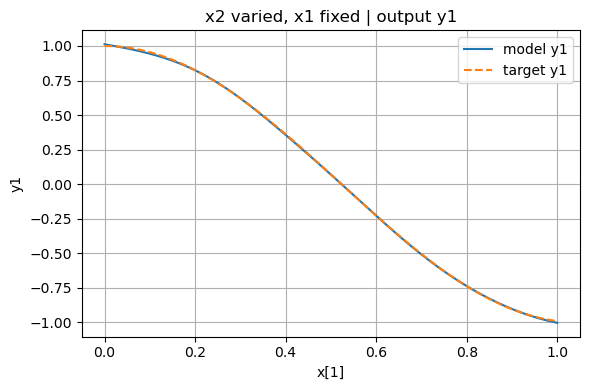

In [697]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.0, 0.0],
    resolution=400,
    mat_export_prefix="target_approximation",
    mat_export_dir=mat_folder,
)

In [698]:
'''
import itertools
import pandas as pd
from scipy.io import savemat

# -------------------------------------------------------------------
# Choose the pool of basis indices you want to search over
# -------------------------------------------------------------------
# Full search over all available basis functions:
# candidate_indices_pool = list(range(b_coef.shape[0]))

# More practical restricted search, example:
candidate_indices_pool = list(range(6, 25))   # edit this range as desired

selection_length = 8

all_index_sets = list(itertools.combinations(candidate_indices_pool, selection_length))

print(f"Number of combinations to test: {len(all_index_sets)}")

# -------------------------------------------------------------------
# Fixed train/test data
# -------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_train = 3000
n_test = 800

x_min_test = 0
x_max_test = 1
input_abs_max = [1.5, 3.0]

x_train = x_min_test + (x_max_test - x_min_test) * torch.rand(n_train, 2)
x_test = x_min_test + (x_max_test - x_min_test) * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    y = 0.3 * x1**2 + torch.cos(3.0 * x2)
    return y

y_train = target_fn(x_train)
y_test = target_fn(x_test)

x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)
x_test = x_test.to(device=device, dtype=torch.float64)
y_test = y_test.to(device=device, dtype=torch.float64)

loss_fn = nn.MSELoss()

num_epochs = 5000
lr = 1e-3

# -------------------------------------------------------------------
# Single training run for one choice of selected_indices
# -------------------------------------------------------------------
def train_one_selection(selected_indices, verbose=False):
    selected_indices = list(selected_indices)
    b_coef_selected = b_coef[selected_indices]

    # Reset seed so every basis choice starts from comparable initialization
    torch.manual_seed(42)
    np.random.seed(42)

    model = KAN(
        in_count=2,
        out_count=1,
        hidden_layer_sizes=[1],
        x_min=float(input_power.min()),
        x_max=float(input_power.max()),
        layer_type="photonic_interval_affine_clean",
        b_coef_selected=b_coef_selected,
        input_abs_max=input_abs_max,
        basis_min=0.05,
        basis_max=2.0,
        dropout_prob=0.0,
        debug=False,
    )

    model = model.to(device=device, dtype=torch.float64)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    best_test_loss = float("inf")
    best_train_loss = float("inf")
    best_epoch = -1

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        train_loss = loss_fn(y_pred, y_train)

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_pred = model(x_test)
            test_loss = loss_fn(y_test_pred, y_test)

        train_loss_value = train_loss.item()
        test_loss_value = test_loss.item()

        train_losses.append(train_loss_value)
        test_losses.append(test_loss_value)

        if test_loss_value < best_test_loss:
            best_test_loss = test_loss_value
            best_train_loss = train_loss_value
            best_epoch = epoch

        if verbose and epoch % 500 == 0:
            print(
                f"indices = {selected_indices} | "
                f"epoch {epoch:5d} | "
                f"train = {train_loss_value:.8e} | "
                f"test = {test_loss_value:.8e}"
            )

    result = {
        "selected_indices": selected_indices,
        "selected_detunings": set_detuning[selected_indices],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
        "best_train_loss": best_train_loss,
        "best_test_loss": best_test_loss,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "model": model,
    }

    return result


# -------------------------------------------------------------------
# Grid search
# -------------------------------------------------------------------
results = []
best_result = None

for combo_id, selected_indices in enumerate(all_index_sets):
    print(
        f"\n[{combo_id + 1}/{len(all_index_sets)}] "
        f"Testing selected_indices = {list(selected_indices)}"
    )

    result = train_one_selection(selected_indices, verbose=False)

    results.append({
        "combo_id": combo_id,
        "selected_indices": result["selected_indices"],
        "selected_detunings": result["selected_detunings"],
        "final_train_loss": result["final_train_loss"],
        "final_test_loss": result["final_test_loss"],
        "best_train_loss": result["best_train_loss"],
        "best_test_loss": result["best_test_loss"],
        "best_epoch": result["best_epoch"],
    })

    print(
        f"Best test loss for this combo: {result['best_test_loss']:.8e} "
        f"at epoch {result['best_epoch']}"
    )

    if best_result is None or result["best_test_loss"] < best_result["best_test_loss"]:
        best_result = result

        print("New best combination found!")
        print("Best selected_indices:", best_result["selected_indices"])
        print("Best selected_detunings:", best_result["selected_detunings"])
        print("Best test loss:", best_result["best_test_loss"])


# -------------------------------------------------------------------
# Save summary results
# -------------------------------------------------------------------
mat_folder = "new_affine_2-1-1_exports"
os.makedirs(mat_folder, exist_ok=True)

df_results = pd.DataFrame(results)
csv_path = os.path.join(mat_folder, "basis_grid_search_results.csv")
df_results.to_csv(csv_path, index=False)

print("\nGrid search finished.")
print("Results saved to:", csv_path)

print("\nBest selected_indices:")
print(best_result["selected_indices"])

print("\nBest selected_detunings:")
print(best_result["selected_detunings"])

print("\nBest test loss:")
print(best_result["best_test_loss"])

# -------------------------------------------------------------------
# Save best result to .mat
# -------------------------------------------------------------------
mat_save_path = os.path.join(mat_folder, "best_basis_grid_search_result.mat")

savemat(
    mat_save_path,
    {
        "best_selected_indices": np.array(best_result["selected_indices"]),
        "best_selected_detunings": np.array(best_result["selected_detunings"]),
        "best_train_loss": np.array(best_result["best_train_loss"]),
        "best_test_loss": np.array(best_result["best_test_loss"]),
        "best_epoch": np.array(best_result["best_epoch"]),
        "train_losses": np.array(best_result["train_losses"]),
        "test_losses": np.array(best_result["test_losses"]),
    },
)

print("Best result saved to:", mat_save_path)
'''

'\nimport itertools\nimport pandas as pd\nfrom scipy.io import savemat\n\n# -------------------------------------------------------------------\n# Choose the pool of basis indices you want to search over\n# -------------------------------------------------------------------\n# Full search over all available basis functions:\n# candidate_indices_pool = list(range(b_coef.shape[0]))\n\n# More practical restricted search, example:\ncandidate_indices_pool = list(range(6, 25))   # edit this range as desired\n\nselection_length = 8\n\nall_index_sets = list(itertools.combinations(candidate_indices_pool, selection_length))\n\nprint(f"Number of combinations to test: {len(all_index_sets)}")\n\n# -------------------------------------------------------------------\n# Fixed train/test data\n# -------------------------------------------------------------------\ntorch.manual_seed(42)\nnp.random.seed(42)\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nn_train = 3000\nn_test 